In [2]:
!pip install zstandard # dataset compression

In [1]:
import regex as re
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt
import mpl_toolkits.axisartist.axislines as axislines

In [ ]:
df = pd.read_csv('results/annotated_GLM-4.7-Flash.zst', low_memory=False)
df

In [ ]:
df['regex_answer'] = df.llm_response.str.extract(r'(Trump|Harris|Non-voter)', expand=False)

In [ ]:
# add parsing method to specifications
df_regex = df.melt(
    id_vars=[c for c in df.columns if "answer" not in c],
    value_vars=['answer', 'regex_answer'],
    value_name='parsed_answer',
    var_name='parsing_method'
)
df_regex['parsing_method'] = df_regex.parsing_method.replace({'answer': 'LLMjudge', 'regex_answer': 'regex'})

# regex parsing is not applicable to json responses
df_regex = df_regex[
    ~((df_regex.response_type == 'jsonResponse') & (df_regex.parsing_method == 'regex'))
]
df_regex.loc[
    df_regex.response_type == 'jsonResponse',
    'parsing_method'
] = 'jsonParsing'

# convert parsed_answer to str even if regex parsing might have failed
# we define the set of "accepted" labels below to properly handle invalid responses
df_regex['parsed_answer'] = df_regex['parsed_answer'].astype(str)

df_regex

,questionnaire_name,questionnaire_item_id,question,llm_response,logprobs,reasoning,response_type,persona_format,persona_id,sample,model_id,seed,parsing_method,parsed_answer
0,openResponse_firstPerson_0_0,1,Will you vote in the 2024 U.S. presidential el...,Trump\n\nAs a 50-year-old Hispanic man from Ok...,NaN,NaN,openResponse,firstPerson,0,0,Qwen3-VL-8B-Instruct,42,LLMjudge,Trump
1,openResponse_firstPerson_0_0,2,Please tell me if you will vote and if so for ...,Trump\n\nAs a 50-year-old Hispanic man from Ok...,NaN,NaN,openResponse,firstPerson,0,0,Qwen3-VL-8B-Instruct,42,LLMjudge,Trump
2,openResponse_firstPerson_1_0,1,Will you vote in the 2024 U.S. presidential el...,"I’ll vote for Kamala Harris.\n\nAs a moderate,...",NaN,NaN,openResponse,firstPerson,1,0,Qwen3-VL-8B-Instruct,42,LLMjudge,Harris
3,openResponse_firstPerson_1_0,2,Please tell me if you will vote and if so for ...,"I’ll vote for Kamala Harris.\n\nAs a moderate,...",NaN,NaN,openResponse,firstPerson,1,0,Qwen3-VL-8B-Instruct,42,LLMjudge,Harris
4,openResponse_firstPerson_2_0,1,Will you vote in the 2024 U.S. presidential el...,"I will vote for Kamala Harris.\n\nAs a White, ...",NaN,NaN,openResponse,firstPerson,2,0,Qwen3-VL-8B-Instruct,42,LLMjudge,Harris
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3440875,openResponse_demogrInterview_4776_0,2,Please tell me if you will vote and if so for ...,"Based on the provided information, I'll make a...",NaN,NaN,openResponse,demogrInterview,4776,0,Llama-3.3-70B-Instruct,46,regex,Trump
3440876,openResponse_demogrInterview_4777_0,1,Will you vote in the 2024 U.S. presidential el...,Based on demographic trends and voting pattern...,NaN,NaN,openResponse,demogrInterview,4777,0,Llama-3.3-70B-Instruct,46,regex,Harris
3440877,openResponse_demogrInterview_4777_0,2,Please tell me if you will vote and if so for ...,Based on demographic trends and voting pattern...,NaN,NaN,openResponse,demogrInterview,4777,0,Llama-3.3-70B-Instruct,46,regex,Harris
3440878,openResponse_demogrInterview_4778_0,1,Will you vote in the 2024 U.S. presidential el...,"Based on the information provided, I'll make a...",NaN,NaN,openResponse,demogrInterview,4778,0,Llama-3.3-70B-Instruct,46,regex,Harris


In [8]:
anes_df = pd.read_csv('data/2024_anes_preprocessed.csv', index_col=0).reset_index(names='ANES_index')
anes_df['age_bracket'] = (anes_df.age // 10) * 10
anes_df

,ANES_index,pre_weight,post_weight,age,discuss_politics,race,ideology,party,attend_church,gender,political_interest,state,turnout,vote_choice,age_bracket
0,0,0.716602,0.710865,50.0,True,Hispanic,conservative,NaN,True,a man,somewhat,Oklahoma,1,Trump,50.0
1,1,2.354582,2.383786,41.0,True,Asian,moderate; middle of the road,NaN,False,a woman,NaN,Idaho,0,Non-voter,40.0
2,2,0.780178,0.808992,44.0,True,White,liberal,NaN,False,a woman,very,Virginia,1,Harris,40.0
3,3,0.268988,0.291740,45.0,True,Asian,NaN,NaN,True,a man,not very,California,0,Non-voter,40.0
4,4,0.244306,0.222012,80.0,False,White,moderate; middle of the road,NaN,False,a man,not very,Colorado,1,Trump,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4774,5514,0.776746,0.554677,42.0,False,White,moderate; middle of the road,NaN,True,a woman,NaN,Illinois,0,Non-voter,40.0
4775,5515,0.115966,0.075758,80.0,True,Hispanic,slightly liberal,NaN,False,a woman,somewhat,Colorado,1,Harris,80.0
4776,5517,2.910370,1.797863,69.0,True,White,slightly liberal,an independent,True,a woman,somewhat,Minnesota,1,Harris,60.0
4777,5519,2.635201,2.255936,28.0,True,Black,extremely liberal,NaN,False,a man,very,New Jersey,1,Harris,20.0


In [9]:
comb_df = pd.merge(
    left = df_regex,
    right = anes_df,
    left_on = 'persona_id',
    right_index = True,
    how = 'left'
)
comb_df.head()

,questionnaire_name,questionnaire_item_id,question,llm_response,logprobs,reasoning,response_type,persona_format,persona_id,sample,...,race,ideology,party,attend_church,gender,political_interest,state,turnout,vote_choice,age_bracket
0,openResponse_firstPerson_0_0,1,Will you vote in the 2024 U.S. presidential el...,Trump\n\nAs a 50-year-old Hispanic man from Ok...,NaN,NaN,openResponse,firstPerson,0,0,...,Hispanic,conservative,NaN,True,a man,somewhat,Oklahoma,1,Trump,50.0
1,openResponse_firstPerson_0_0,2,Please tell me if you will vote and if so for ...,Trump\n\nAs a 50-year-old Hispanic man from Ok...,NaN,NaN,openResponse,firstPerson,0,0,...,Hispanic,conservative,NaN,True,a man,somewhat,Oklahoma,1,Trump,50.0
2,openResponse_firstPerson_1_0,1,Will you vote in the 2024 U.S. presidential el...,"I’ll vote for Kamala Harris.\n\nAs a moderate,...",NaN,NaN,openResponse,firstPerson,1,0,...,Asian,moderate; middle of the road,NaN,False,a woman,NaN,Idaho,0,Non-voter,40.0
3,openResponse_firstPerson_1_0,2,Please tell me if you will vote and if so for ...,"I’ll vote for Kamala Harris.\n\nAs a moderate,...",NaN,NaN,openResponse,firstPerson,1,0,...,Asian,moderate; middle of the road,NaN,False,a woman,NaN,Idaho,0,Non-voter,40.0
4,openResponse_firstPerson_2_0,1,Will you vote in the 2024 U.S. presidential el...,"I will vote for Kamala Harris.\n\nAs a White, ...",NaN,NaN,openResponse,firstPerson,2,0,...,White,liberal,NaN,False,a woman,very,Virginia,1,Harris,40.0


In [10]:
### Calculate metrics for each simulation specification

specification_cols = [
    'questionnaire_item_id',
    'response_type',
    'persona_format',
    'sample',
    'model_id',
    'parsing_method',
    'seed'
]

demographic_cols = [
    'age_bracket',
    'discuss_politics',
    'race',
    'ideology',
    'party',
    'attend_church',
    'gender',
    'political_interest',
    'state'
]

labels = ['Trump', 'Harris', 'Non-voter']

agg_results = []

for group_spec, group_df in tqdm(comb_df.groupby(specification_cols)):
    group_results = dict(zip(specification_cols, group_spec))

    last_df = group_df

    ### Individual-level accuracy
    report = classification_report(
        group_df['vote_choice'],
        group_df['parsed_answer'],
        labels=labels,
        output_dict=True,
        zero_division=0, # handle non-existing labels
    )

    # Using pre_weight as post_weight contains missing values
    # NOTE that weights mean something slightly different than in surveys
    weighted_report = classification_report(
        group_df['vote_choice'],
        group_df['parsed_answer'],
        labels=labels,
        output_dict=True,
        sample_weight=group_df['pre_weight'],
        zero_division=0, # handle non-existing labels
    )

    ### Marginal distributions
    tvds = []
    weighted_tvds = []

    for dem_col in demographic_cols:
        for dem_val, subgroup in group_df.groupby(dem_col):

            # Ignore survey weights and just count vote choices
            true_vals = subgroup.groupby('vote_choice')['pre_weight'].count()
            # Fill-in zeros for labels that did not occur and normalize
            true_dist = pd.Series({
                label: true_vals.get(label, default=0) / true_vals.sum()
                for label in labels
            })
            pred_vals = subgroup.groupby('parsed_answer')['pre_weight'].count()
            # Fill-in zeros for labels that did not occur and normalize
            pred_dist = pd.Series({
                label: pred_vals.get(label, default=0) / pred_vals.sum()
                for label in labels
            })

            tvds.append({
                'subgroup_size': len(subgroup),
                'tvd': 0.5 * np.abs(true_dist - pred_dist).sum(),
            })

            # Account for survey weights by calculating the sum
            true_weighted_vals = subgroup.groupby('vote_choice')['pre_weight'].sum() # <- the sum() is crucial
            # Fill-in zeros for labels that did not occur and normalize
            true_weighted_dist = pd.Series({
                label: true_weighted_vals.get(label, default=0) / true_weighted_vals.sum()
                for label in labels
            })
            pred_weighted_vals = subgroup.groupby('parsed_answer')['pre_weight'].sum()
            # Fill-in zeros for labels that did not occur and normalize
            pred_weighted_dist = pd.Series({
                label: pred_weighted_vals.get(label, default=0) / pred_weighted_vals.sum()
                for label in labels
            })

            weighted_tvds.append({
                'subgroup_size': len(subgroup),
                'tvd': 0.5 * np.abs(true_weighted_dist - pred_weighted_dist).sum(),
            })

    tvd_df = pd.DataFrame(tvds)
    weighted_tvd_df = pd.DataFrame(weighted_tvds)

    ### Combine the evaluation results into a report
    group_results = group_results | {
        'simulated_responses': len(group_df),
        'valid_responses': len(group_df[group_df.parsed_answer != 'nan']),
        
        # accuracy can be nan if values could not be parsed
        'accuracy': report['accuracy'] if 'accuracy' in report else np.nan,
        'weighted_accuracy': weighted_report['accuracy'] if 'accuracy' in weighted_report else np.nan,

        'macro_avg_f1': report['macro avg']['f1-score'],
        'weighted_f1': weighted_report['weighted avg']['f1-score'],
    }

    # Add f1-score for each label (Trump, Harris, Non-voter)
    for label in labels:
        group_results = group_results | {
            f'f1_{label}': report[label]['f1-score'],
        }
    
    # Add unweighted & weighted Total Variation Distance, optionally ignore subgroups that are too small
    for cutoff in [0, 10, 50, 100]:
        if cutoff == 0: cutoff_str = ''
        else: cutoff_str = str(cutoff)

        group_results = group_results | {
            # TVD without accounting for survey weights
            f'tvd{cutoff_str}_avg': tvd_df[tvd_df.subgroup_size >= cutoff]['tvd'].mean(),
            f'tvd{cutoff_str}_std': tvd_df[tvd_df.subgroup_size >= cutoff]['tvd'].std(),

            # TVD based on weighted distributions
            f'weighted_tvd{cutoff_str}_avg': weighted_tvd_df[weighted_tvd_df.subgroup_size >= cutoff]['tvd'].mean(),
            f'weighted_tvd{cutoff_str}_std': weighted_tvd_df[weighted_tvd_df.subgroup_size >= cutoff]['tvd'].std(),
        }

    agg_results.append(group_results)

agg_results_df = pd.DataFrame(agg_results)

  0%|          | 0/720 [00:00<?, ?it/s]

In [2]:
#agg_results_df.to_csv('results/evaluated_results.csv', index=False)
agg_results_df = pd.read_csv('results/evaluated_results.csv')

In [3]:
agg_results_df.sort_values('weighted_tvd100_avg')

,questionnaire_item_id,response_type,persona_format,sample,model_id,parsing_method,seed,simulated_responses,valid_responses,accuracy,...,weighted_tvd10_avg,weighted_tvd10_std,tvd50_avg,tvd50_std,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std
633,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,45,4779,4779,0.680268,...,0.110146,0.076144,0.088166,0.054792,0.095154,0.067997,0.083346,0.055254,0.085072,0.064138
600,2,openResponse,firstPerson,0,Llama-3.1-8B-Instruct,LLMjudge,42,4779,4779,0.633605,...,0.119003,0.080048,0.085451,0.047370,0.097955,0.063432,0.079327,0.042461,0.086328,0.045348
631,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,43,4779,4779,0.680686,...,0.116459,0.094726,0.086409,0.055547,0.091210,0.069153,0.080503,0.056933,0.086815,0.068552
632,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,44,4779,4779,0.673572,...,0.119426,0.090449,0.087621,0.055649,0.097442,0.070714,0.083013,0.054760,0.088154,0.064074
75,1,jsonResponse,firstPerson,0,Olmo-3.1-32B-Instruct,jsonParsing,42,4779,4779,0.684871,...,0.116326,0.092869,0.079371,0.055473,0.096109,0.070733,0.074936,0.059329,0.090308,0.071274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,46,4779,4571,NaN,...,0.476144,0.142535,0.474976,0.150654,0.475456,0.141728,0.472156,0.162112,0.472138,0.150103
567,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,44,4779,4553,NaN,...,0.471835,0.150573,0.478021,0.155134,0.478444,0.152875,0.473780,0.165065,0.473097,0.157228
566,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,43,4779,4568,NaN,...,0.477603,0.150887,0.483765,0.154975,0.479003,0.147849,0.477580,0.163308,0.473988,0.153175
565,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,42,4779,4582,NaN,...,0.478932,0.145559,0.479866,0.153751,0.475574,0.147729,0.477182,0.165115,0.476431,0.153358


In [4]:
plot_df = agg_results_df.copy()
plot_df['Survey Question'] = plot_df.questionnaire_item_id.replace({1: 'Version 1', 2: 'Version 2'})
plot_df['response_type'] = plot_df.response_type.replace({'jsonResponse': 'JSON structured output', 'openResponse': 'open-ended response'})
plot_df['parsing_method'] = plot_df.parsing_method.replace({'jsonParsing': 'JSON parsing', 'regex': 'regex parsing', 'LLMjudge': 'LLM-as-a-judge'})
plot_df['Persona Information'] = plot_df.persona_format.apply(lambda x:'demographic only' if 'demogr' in x else 'demographics & attitudes')
plot_df['Persona Format'] = plot_df.persona_format.apply(lambda x:'first person' if 'Person' in x else 'interview')

plot_df = plot_df.drop(columns=['questionnaire_item_id', 'persona_format', 'sample'])
plot_df = plot_df.rename(columns={
    'response_type': 'Output Generation',
    'model_id': 'LLM model ID',
    'parsing_method': 'Output Parsing',
})
plot_df

,Output Generation,LLM model ID,Output Parsing,seed,simulated_responses,valid_responses,accuracy,weighted_accuracy,macro_avg_f1,weighted_f1,...,tvd50_std,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std,Survey Question,Persona Information,Persona Format
0,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,42,4779,4779,0.473739,0.482052,0.369138,0.443994,...,0.123082,0.249947,0.102428,0.285841,0.115613,0.256329,0.101207,Version 1,demographic only,first person
1,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,43,4779,4779,0.480226,0.487383,0.350443,0.430191,...,0.124687,0.298721,0.104813,0.339670,0.124758,0.306578,0.102671,Version 1,demographic only,first person
2,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,44,4779,4779,0.478552,0.485143,0.353808,0.430031,...,0.126018,0.298958,0.105440,0.338620,0.127120,0.304260,0.103445,Version 1,demographic only,first person
3,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,45,4779,4779,0.480226,0.485528,0.349917,0.429834,...,0.124145,0.293930,0.104263,0.339509,0.124337,0.300749,0.100156,Version 1,demographic only,first person
4,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,46,4779,4779,0.481272,0.491380,0.352592,0.436142,...,0.122546,0.294043,0.104805,0.339804,0.124384,0.302291,0.100501,Version 1,demographic only,first person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,42,4779,4779,0.662063,0.633693,0.522161,0.589213,...,0.075581,0.195018,0.084009,0.183785,0.065994,0.190591,0.072004,Version 2,demographics & attitudes,interview
716,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,43,4779,4779,0.657460,0.630315,0.515899,0.584497,...,0.079437,0.209321,0.088124,0.196416,0.070474,0.205527,0.076597,Version 2,demographics & attitudes,interview
717,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,44,4779,4779,0.660180,0.630750,0.516177,0.585092,...,0.078250,0.208338,0.085941,0.193138,0.068522,0.202314,0.075235,Version 2,demographics & attitudes,interview
718,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,45,4779,4779,0.662272,0.634518,0.521115,0.588717,...,0.078456,0.205257,0.087040,0.193565,0.069739,0.200346,0.079350,Version 2,demographics & attitudes,interview


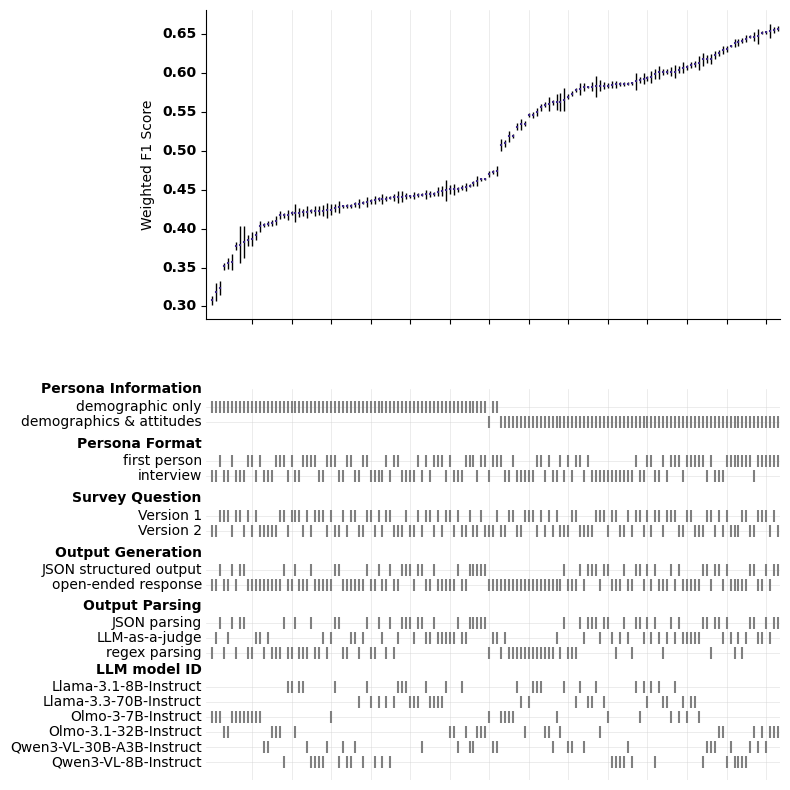

In [40]:
MEASURES = [
    #('Corr. of Quality Estimate with Ground-Truth', 'year_quality_fullData_pearson_r', 'year_quality_pearson', False), # display name, col in df, file name, lower is better
    #('Total Variation Distance\n(Mean Over Subgroups ≥ 100)', 'tvd100_avg', 'tvd100_avg', True),
    #('Total Variation Distance\n(Mean Over Subgroups ≥ 100,\nAccounting for Survey Weights)', 'weighted_tvd100_avg', 'weighted_tvd100_avg', True),
    ('Weighted F1 Score', 'weighted_f1', 'weighted_f1', False)
]
GROUP_COLS = ['Persona Information', 'Persona Format', 'Survey Question', 'Output Generation', 'Output Parsing', 'LLM model ID']

INVALID_THRESHOLD = 0.1 # do not plot results with more invalid responses

plot_df = plot_df.sort_values(by=GROUP_COLS)

for measure_title, measure_col, measure_short, lower_is_better in MEASURES[:]:

    # ---- Aggregate over specifications ----
    agg = plot_df
    #agg.loc[agg[measure_col] > 1, measure_col] = np.nan # exclude invalid values
    agg = plot_df.groupby(GROUP_COLS, observed=True)[measure_col].agg(["mean", "std", "max", "min"])
    #agg['invalid'] = plot_df.groupby(GROUP_COLS, observed=True)['total_invalid'].mean()
#
    ## Exclude invalid responses
    #invalid_agg = (agg.invalid > INVALID_THRESHOLD) #TODO: fix too large/inf values
    #if invalid_agg.any():
    #    print(f'Not plotting the following datapoints because of too many invalid responses:')
    #    display(agg[invalid_agg].sort_values('invalid'))
    #agg.loc[invalid_agg, ['mean', 'std']] = np.nan
    

    # ---- Sort by mean metric ----
    agg = agg.sort_values("mean", ascending=(not lower_is_better), na_position='first').reset_index()

    # ---- Colors for methods ----
    #method_colors = {m: c for m, c in zip(sorted(agg["answer_production_method"].unique()), plt.cm.tab10.colors)}
    #method_colors = {m:c for m, c in zip(method_names.values(), hue_colors)}
    method_colors = {}

    # ---- Plot ----
    #fig, (ax_curve, ax_specs) = plt.subplots(
    #    2, 1, figsize=(5, 6), gridspec_kw={'height_ratios': [2.5, 3]}, sharex=True
    #)

    fig = plt.figure(figsize=(8, 8)) #(6, 6)

    # Create your grid manually, like plt.subplots does internally
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1.9])

    # First subplot
    ax_curve = fig.add_subplot(gs[0], axes_class=axislines.Axes)
    # Second subplot
    ax_specs = fig.add_subplot(gs[1], axes_class=axislines.Axes, sharex=ax_curve)


    # Top: specification curve
    for j in range(len(agg)):
        #method = agg.loc[j, 'Survey Response Generation Method']
        method = ''
        color = method_colors.get(method, "#3A2684")
        ax_curve.errorbar(
            x=j,
            y=agg.loc[j, "mean"],
            yerr=agg.loc[j, "std"],
            #fmt="o",
            fmt='|',
            ecolor='black',
            elinewidth=1,
            capsize=0,
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=2, #3
            markeredgewidth=1.5
        )

    ax_curve.set_ylabel(measure_title)
    #ax_curve.legend(frameon=False)
    ax_curve.set_xlim([-0.5, len(agg)-0.5])

    # Bottom: indicator lines for each unique value of each variable
    # Reversed order: model_id on top, then answer_production_method, answer_scale_variant, temperature
    var_order = GROUP_COLS.copy()
    var_order.reverse()

    # Assign y-positions for each unique value within each variable
    y_positions = {}
    base_y = 1
    y_offset = 1.1
    ytick_labels = []
    major_ytick_labels = [] # headings
    ytick_positions = []
    major_ytick_positions = []
    separators = []
    for var in var_order:
        unique_vals = plot_df[var].unique()[::-1]
        for k, val in enumerate(unique_vals):
            y_positions[(var, str(val))] = base_y + k*y_offset
            ytick_labels.append(str(val))
            ytick_positions.append(base_y + k*y_offset)
            separators.append(base_y + k*y_offset)
        if var == 'Survey Response Generation Method':
            major_ytick_labels.append('Survey Response\nGeneration Method')
        else:
            major_ytick_labels.append(var)
        major_ytick_positions.append(base_y + (k + .7)*y_offset)
        base_y += len(unique_vals) + 2  # gap between groups
        if var == 'model': base_y += 1  # fix spacing

    # Plot markers and horizontal lines for each configuration
    for j in range(len(agg)):
        for var in var_order:
            val = str(agg.loc[j, var])
            y = y_positions[(var, val)]
            if np.isnan(agg.loc[j, 'mean']).any():
                color = "lightgray"
            elif var == 'Survey Response Generation Method':
                color = method_colors.get(val, "gray")
            else:
                color = "gray"
            # optionally, always color the bars according to the method -> overwhelming
            #else:
            #    _method = str(agg.loc[j, 'Survey Response Generation Method'])
            #    color = method_colors.get(_method, "gray")
            ax_specs.plot(j, y, marker="|", color=color, markersize=8, markeredgewidth=1.5)

    # Add horizontal lines for each configuration row
    for y in ytick_positions:
        ax_specs.axhline(y, color="lightgray", linestyle="-", linewidth=0.5, alpha=0.6, zorder=0)
    
    step = 10 #int(len(agg)/10)
    _vlines = list(range(step, len(agg), step))
    #_vlines = [i-0.25 for i in range(len(agg)-10,0,-10)]
    for x in _vlines:
        ax_specs.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)
        ax_curve.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)

    # Format y-axis
    ax_specs.set_yticks(ytick_positions, labels=ytick_labels, fontsize='small', minor=True)
    ax_specs.tick_params(axis='y', which='minor', labelsize='small')
    ax_specs.set_yticks(major_ytick_positions, labels=major_ytick_labels, fontsize=10)
    ax_specs.axis['left'].major_ticklabels.set(ha='right', va='bottom', fontsize=10, fontweight='bold', linespacing=1.1) #pad=-70,
    ax_specs.axis['left'].minor_ticklabels.set(fontsize=10)

    # Adjust x-axis and extra borders
    labels = ['' for i in _vlines] #[str(i) for i in range(10,len(agg),10)]
    ax_curve.set_xticks(_vlines, labels=labels)
    ax_curve.set_xlabel(None) #\nranked by {measure_title}
    ax_curve.axis['bottom'].major_ticklabels.set(fontsize=10)
    ax_curve.axis['bottom'].label.set(fontsize=10)
    ax_curve.axis['bottom'].major_ticks.set_tick_out(True)
    ax_curve.axis['left'].major_ticklabels.set(fontsize=10, fontweight='bold', color='black') #'#3A2684'
    ax_curve.axis['left'].label.set(fontsize=10)
    ax_curve.axis['left'].major_ticks.set_tick_out(True)
    ax_specs.axis['bottom'].major_ticklabels.set_visible(False)
    #ax_specs.axis['bottom'].major_ticks.set_tick_out(True)

    # Add an arrow to the left spine depending on which direction is better
    #ax_curve.axis['left'].set_axisline_style("-|>", size=1.5)

    for spine in ["top", "right"]:
        ax_specs.axis[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax_specs.axis[spine].line.set_visible(False) # remove spine
        ax_specs.axis[spine].major_ticks.set_ticksize(0) # remove ticks
        ax_specs.axis[spine].minor_ticks.set_ticksize(0) # remove ticks
    for spine in ["top", "right"]:
        ax_curve.axis[spine].set_visible(False)
    
    xmin, xmax = ax_curve.get_xlim()
    ax_curve.set_xlim(xmin-1, xmax) # add padding next to spine

    #ax_curve.set_ylim(0.82,1)

    ymin, ymax = ax_specs.get_ylim()
    #ax_specs.set_ylim(ymin, ymax + 0.8) # add padding for heading

    # Get the bounding box of the axes including ticklabels
    bbox = ax_curve.get_tightbbox(fig.canvas.get_renderer())
    # Center-align Figure title
    bbox = bbox.transformed(fig.transFigure.inverted()) # Convert bbox to figure coordinates
    x_center = 0.57 * (bbox.x0 + bbox.x1) # Compute center x in figure coordinates

    #fig.text(x_center, bbox.y1 + 0.11, "Annotator quality:\nMTME estimate ⟷ Gold-standard",
    #         ha='center', va='bottom', fontsize=10) #fontweight='bold'

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    #plt.savefig(f'../plots/MTME_multiverse/specificationCurve_{measure_short}.pdf', bbox_inches='tight')
    plt.show()